# Jointure exacte HubSpot ↔ DB par numéro de devis

Remplace le matching flou par nom de client (`sprint_dotplot.ipynb`) par une jointure
**exacte** : `Sales Quote Number` (CSV HubSpot) = `public.sector_campaign.quote_number` (DB).

`sector_campaign` porte les indicateurs de qualité de données
(`year_unknown_percentage`, `diameter_unknown_percentage`, `unknown_material_percentage`)
**figés au moment du Sprint** : calculés par l'app depuis le CSV de campagne
(object storage, `data_path`), pondérés par la longueur, avec inconnu =
diamètre `NULL`/`0`, année `NULL`/sentinelle 1700, matériau `"Unknown"`.

La cellule « évolution des données » recalcule ces mêmes indicateurs (même
méthodologie) sur `platformv2.network_arc` — le réseau client le plus à jour,
utilisé par TWIN — via un rapprochement spatial (rayon 10 m). L'écart mesure
donc l'**évolution des données client depuis le Sprint**, pas une erreur.

⚠️ Un devis peut couvrir plusieurs campagnes (secteurs) ET plusieurs sprints HubSpot
(ex : Gourdon 1 & 2 partagent D-2025-500). Les stats DB sont agrégées par devis,
pondérées par la longueur des secteurs.

In [6]:
import sys, pathlib, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from urllib.parse import parse_qs

sys.path.insert(0, str(pathlib.Path().resolve()))
from sprint_loader import SprintLoader

In [7]:
# ── sprints HubSpot avec numéros de devis ────────────────────────────────────
loader     = SprintLoader()
df_sprints = loader.load()

print(f"Export : {loader.export_date} — {len(df_sprints)} sprints")
print(f"Devis renseignés : {df_sprints.quote_number.notna().sum()}/{len(df_sprints)}")
dup = df_sprints.quote_number.duplicated(keep=False)
if dup.any():
    print(f"\nDevis partagés par plusieurs sprints ({dup.sum()} sprints) :")
    print(df_sprints[dup][["quote_number", "n"]].sort_values("quote_number")
          .to_string(index=False))

Export : 20260622 — 77 sprints
Devis renseignés : 77/77

Devis partagés par plusieurs sprints (9 sprints) :
quote_number                                                          n
  D-2024-383                                   PIA_2025 - 1ere campagne
  D-2024-383                                x3 PIA 2025 - 2eme campagne
  D-2024-383                     REGIE DES EAUX DE PIA  - 3eme campagne
  D-2025-419 COMMUNAUTE D'AGGLOMERATION DU GRAND VERDUN - 2eme campagne
  D-2025-419  COMMUNAUTE D'AGGLOMERATION DU GRAND VERDUN -1ere campagne
  D-2025-500                            Mairie de Gourdon I 2eme Sprint
  D-2025-500                                          MAIRIE DE GOURDON
  D-2026-627                                REGIE DE LEAU DE SALLANCHES
  D-2026-627               REGIE DE LEAU DE SALLANCHES (2ème itération)


In [8]:
# ── connexion DB (read replica) ──────────────────────────────────────────────
load_dotenv()
jdbc_url = os.getenv("APP_DB_JDBC_URL")

if jdbc_url and jdbc_url.startswith("jdbc:postgresql://"):
    host_db, _, query_str = jdbc_url.replace("jdbc:postgresql://", "").partition("?")
    params   = parse_qs(query_str)
    user     = params.get("user", [""])[0]
    password = params.get("password", [""])[0]
    sslmode  = params.get("sslmode", ["require"])[0]
    engine = create_engine(
        f"postgresql://{user}:{password}@{host_db}?sslmode={sslmode}"
    )
    print("connection successful !")
else:
    raise RuntimeError("APP_DB_JDBC_URL absent ou illisible (.env)")

connection successful !


In [9]:
# ── stats qualité de données par devis (sector_campaign) ────────────────────
# Moyennes pondérées par la longueur du secteur ; FILTER exclut proprement les
# campagnes où l'indicateur est NULL (numérateur ET dénominateur).
query = text("""
SELECT
    UPPER(TRIM(sc.quote_number))                       AS quote_number,
    STRING_AGG(DISTINCT o.name, ' | ')                 AS client,
    COUNT(*)                                           AS nb_campagnes,
    ROUND(SUM(sc.length)::numeric / 1000.0, 1)         AS km_total,
    ROUND((SUM(sc.year_unknown_percentage * sc.length)
               FILTER (WHERE sc.year_unknown_percentage IS NOT NULL))::numeric
          / NULLIF(SUM(sc.length)
               FILTER (WHERE sc.year_unknown_percentage IS NOT NULL), 0),
          1)                                           AS pct_year_unknown,
    ROUND((SUM(sc.diameter_unknown_percentage * sc.length)
               FILTER (WHERE sc.diameter_unknown_percentage IS NOT NULL))::numeric
          / NULLIF(SUM(sc.length)
               FILTER (WHERE sc.diameter_unknown_percentage IS NOT NULL), 0),
          1)                                           AS pct_diameter_unknown,
    ROUND((SUM(sc.unknown_material_percentage * sc.length)
               FILTER (WHERE sc.unknown_material_percentage IS NOT NULL))::numeric
          / NULLIF(SUM(sc.length)
               FILTER (WHERE sc.unknown_material_percentage IS NOT NULL), 0),
          1)                                           AS pct_material_unknown
FROM public.sector_campaign sc
JOIN public.sector       s ON s.id = sc.sector_id
JOIN public.organization o ON o.id = s.organization_id
WHERE sc.quote_number IS NOT NULL AND TRIM(sc.quote_number) <> ''
GROUP BY UPPER(TRIM(sc.quote_number));
""")

df_quotes = pd.read_sql_query(query, engine)
print(f"{len(df_quotes)} devis distincts en base")
df_quotes.head(15)

115 devis distincts en base


,quote_number,client,nb_campagnes,km_total,pct_year_unknown,pct_diameter_unknown,pct_material_unknown
0,ADE-001,Agglomeration_Tarbes_Lourdes_Pyrenees,13,0.4,NaN,NaN,NaN
1,ADE-004,Decazeville_communaute,89,1.2,NaN,NaN,NaN
2,ADE-005,Syndicat_Adour_Coteaux,18,0.5,NaN,NaN,NaN
3,ADE-009,Syndicat_SMEC82,59,1.4,NaN,NaN,NaN
4,D-2022-119,Regie_Ville_PAEA,1,0.1,NaN,NaN,NaN
5,D-2023-142,Rese17,1,0.1,NaN,NaN,NaN
6,D-2023-146,SAUR_SIAEP,2,0.2,NaN,NaN,NaN
7,D-2023-147,SAUR_SIAEP,4,0.4,NaN,NaN,NaN
8,D-2023-149,Syndicat_SMEC82,1,0.1,NaN,NaN,NaN
9,D-2023-152,Agglopolys Blois,2,0.1,NaN,NaN,NaN


In [10]:
# ── évolution des données : CSV du Sprint vs réseau TWIN actuel ──────────────
# Les % stockés dans sector_campaign ont été calculés depuis le CSV de campagne
# (object storage, data_path) AU MOMENT du Sprint, pondérés par la longueur.
# Le CSV n'est pas requêtable en SQL, mais la DB en garde deux traces :
#   - assignment_progression_pipe : tronçons parcourus (length = Length_pipe du
#     CSV, géométrie location1/location2) — aucune FK réseau, pipe_id local au CSV
#   - les % figés de sector_campaign
# On recalcule ici les mêmes indicateurs, avec la MÊME méthodologie que l'app
# (pondération par la longueur CSV, inconnu = diamètre NULL/0, année NULL/1700,
# matériau NULL/'Unknown'), mais sur platformv2.network_arc = le réseau client
# LE PLUS À JOUR (TWIN). Le seul lien possible est spatial : point milieu du
# tronçon → arc le plus proche dans un rayon de 10 m (GiST + KNN).
#
# ⚠️ Interprétation : un écart stocké vs recalculé mesure l'ÉVOLUTION des données
# client depuis le Sprint (enrichissement, corrections), PAS une erreur de calcul.
import time

MAX_QUOTES = None   # limiter à N devis pour un test rapide (None = tous)

RECALC_SQL = text("""
WITH pipes AS (
    SELECT DISTINCT ON (app.pipe_id)
        app.pipe_id,
        app.length AS csv_length,
        pn.id AS net_id,
        ST_LineInterpolatePoint(
            ST_MakeLine(app.location1::geometry, app.location2::geometry), 0.5
        ) AS midpoint
    FROM public.sector_campaign sc
    JOIN public.sector s       ON s.id = sc.sector_id
    JOIN platformv2.network pn ON pn.organization_id = s.organization_id
    JOIN public.assignment_progression_pipe app ON app.sector_campaign_id = sc.id
    WHERE UPPER(TRIM(sc.quote_number)) = :quote
),
matched AS (
    SELECT p.pipe_id, p.csv_length,
           (arc.id IS NOT NULL)                        AS is_matched,
           (nc.installation_year_start IS NULL
            OR nc.installation_year_start = 1700)      AS year_unknown,
           (arc.diameter IS NULL OR arc.diameter = 0)  AS diameter_unknown,
           (arc.material IS NULL
            OR UPPER(arc.material) = 'UNKNOWN')        AS material_unknown
    FROM pipes p
    LEFT JOIN LATERAL (
        SELECT a.id, a.diameter, a.material, a.network_common_id
        FROM platformv2.network_arc a
        WHERE a.network_id = p.net_id
          AND ST_DWithin(a.geometry::geography, p.midpoint::geography, 10)
        ORDER BY a.geometry <-> p.midpoint
        LIMIT 1
    ) arc ON true
    LEFT JOIN platformv2.network_common nc ON nc.id = arc.network_common_id
)
SELECT
    COUNT(*)                                                       AS pipes,
    COUNT(*) FILTER (WHERE is_matched)                             AS matched,
    ROUND((100.0 * COALESCE(SUM(csv_length) FILTER (WHERE is_matched AND year_unknown), 0)
           / NULLIF(SUM(csv_length) FILTER (WHERE is_matched), 0))::numeric, 1)
                                                                   AS year_unknown_now,
    ROUND((100.0 * COALESCE(SUM(csv_length) FILTER (WHERE is_matched AND diameter_unknown), 0)
           / NULLIF(SUM(csv_length) FILTER (WHERE is_matched), 0))::numeric, 1)
                                                                   AS diameter_unknown_now,
    ROUND((100.0 * COALESCE(SUM(csv_length) FILTER (WHERE is_matched AND material_unknown), 0)
           / NULLIF(SUM(csv_length) FILTER (WHERE is_matched), 0))::numeric, 1)
                                                                   AS material_unknown_now
FROM matched
""")

# devis des sprints HubSpot présents en base (df_sprints + df_quotes définis plus haut)
sprint_quotes = set(df_sprints["quote_number"].dropna()) \
              | set(df_sprints["quote_number_2"].dropna())
quotes_todo = sorted(sprint_quotes & set(df_quotes["quote_number"]))
if MAX_QUOTES:
    quotes_todo = quotes_todo[:MAX_QUOTES]
print(f"{len(quotes_todo)} devis à recalculer (jointure spatiale, qq secondes chacun)\n")

rows = []
with engine.connect() as conn:
    for i, q in enumerate(quotes_todo, 1):
        t0 = time.time()
        r = conn.execute(RECALC_SQL, {"quote": q}).fetchone()
        rows.append({"quote_number": q, **r._mapping})
        m = r._mapping
        print(f"[{i:>2}/{len(quotes_todo)}] {q:<12} "
              f"{m['matched']:>6}/{m['pipes']:<6} pipes matchés "
              f"({time.time()-t0:>3.0f}s)")

df_recalc = pd.DataFrame(rows)
for col in df_recalc.columns.drop("quote_number"):
    df_recalc[col] = pd.to_numeric(df_recalc[col], errors="coerce")
df_recalc["couverture_pct"] = (100 * df_recalc["matched"]
                               / df_recalc["pipes"].replace(0, np.nan)).round(1)

low_cov = df_recalc[df_recalc["couverture_pct"] < 95]
if not low_cov.empty:
    print("\n⚠ Couverture spatiale <95% (recalc à prendre avec précaution) :")
    print(low_cov[["quote_number", "pipes", "matched", "couverture_pct"]]
          .to_string(index=False))

# ── comparaison : état au Sprint (stocké) vs état actuel (recalculé) ─────────
df_check = df_quotes.merge(df_recalc, on="quote_number", how="inner")

PAIRS = [
    ("pct_year_unknown",     "year_unknown_now"),
    ("pct_diameter_unknown", "diameter_unknown_now"),
    ("pct_material_unknown", "material_unknown_now"),
]

# les ROUND PostgreSQL renvoient des Decimal → dtype object : coercer partout
for stored, now in PAIRS:
    df_check[stored] = pd.to_numeric(df_check[stored], errors="coerce")
    df_check[now]    = pd.to_numeric(df_check[now],    errors="coerce")

print(f"\n{len(df_check)} devis comparables\n")
deltas = []
for stored, now in PAIRS:
    d = df_check.dropna(subset=[stored, now])
    if d.empty:
        print(f"{stored:<24} aucun devis comparable")
        continue
    delta = d[stored] - d[now]   # positif = données améliorées depuis le Sprint
    print(f"{stored:<24} n={len(d):>3} · delta médian {delta.median():+5.1f} pts "
          f"· moyen {delta.mean():+5.1f} pts (positif = amélioration depuis le Sprint)")
    deltas.append(
        d.assign(indicateur=stored, delta=delta)
         [["quote_number", "client", "indicateur", stored, now, "delta", "couverture_pct"]]
         .rename(columns={stored: "au_sprint", now: "actuel"})
    )

if deltas:
    evolution = pd.concat(deltas, ignore_index=True)
    evolution["abs_delta"] = evolution["delta"].abs()
    print("\nPlus fortes évolutions depuis le Sprint :")
    print(evolution.sort_values("abs_delta", ascending=False)
          .drop(columns="abs_delta")
          .head(15).to_string(index=False))
else:
    print("\nAucune évolution mesurable (pas de devis avec stocké ET recalculé).")

68 devis à recalculer (jointure spatiale, qq secondes chacun)

[ 1/68] ADE-001       14146/14166  pipes matchés (  9s)
[ 2/68] ADE-004           0/0      pipes matchés (  0s)
[ 3/68] ADE-005       13491/13491  pipes matchés (  2s)
[ 4/68] ADE-009           0/0      pipes matchés (  0s)
[ 5/68] D-2023-186        0/0      pipes matchés (  0s)
[ 6/68] D-2024-215        0/0      pipes matchés (  0s)
[ 7/68] D-2024-222        0/0      pipes matchés (  0s)
[ 8/68] D-2024-228     3391/3736   pipes matchés (  8s)
[ 9/68] D-2024-257        0/0      pipes matchés (  0s)
[10/68] D-2024-261        0/0      pipes matchés (  0s)
[11/68] D-2024-276        0/0      pipes matchés (  0s)
[12/68] D-2024-278        0/0      pipes matchés (  0s)
[13/68] D-2024-287        0/0      pipes matchés (  0s)
[14/68] D-2024-289        0/0      pipes matchés (  0s)
[15/68] D-2024-292        0/0      pipes matchés (  0s)
[16/68] D-2024-293     9773/9848   pipes matchés ( 47s)
[17/68] D-2024-295        0/0      pipes 

OperationalError: (psycopg2.OperationalError) SSL connection has been closed unexpectedly

(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [ ]:
# ── jointure exacte sur quote_number (fallback quote_number_2) ───────────────
df_cmp = df_sprints.merge(df_quotes, on="quote_number", how="left")

# fallback : lignes non appariées, retenter avec quote_number_2
miss = df_cmp["client"].isna() & df_cmp["quote_number_2"].notna() \
       & (df_cmp["quote_number_2"] != df_cmp["quote_number"])
if miss.any():
    fb = (df_cmp.loc[miss, ["quote_number_2"]]
          .merge(df_quotes, left_on="quote_number_2",
                 right_on="quote_number", how="left", suffixes=("", "_fb")))
    for col in df_quotes.columns.drop("quote_number"):
        df_cmp.loc[miss, col] = fb[col].values

matched = df_cmp["client"].notna()
print(f"{matched.sum()}/{len(df_cmp)} sprints appariés par devis (jointure exacte)")
print("\nSprints sans correspondance en base :")
print(df_cmp.loc[~matched, ["n", "quote_number"]].to_string(index=False))

df_cmp = df_cmp[matched].copy()
df_cmp[["n", "client", "quote_number", "gain_pct",
        "pct_year_unknown", "pct_diameter_unknown", "pct_material_unknown"]]

73/77 sprints appariés par devis (jointure exacte)

Sprints sans correspondance en base :
                                                                      n quote_number
SYNDICAT INTERCOMMUNAL D'ADDUCTION D'EAU POTABLE DE LA VIGNE AUX CHAMPS   D-2026-584
                                                                SEMIDAO   D-2026-650
          SIEPV SYNDICAT INTERCOMMUNAL DES EAUX DE LA PLAINE DE VALENCE   D-2025-517
                                                              CCBRC - 2   D-2025-522


,n,client,quote_number,gain_pct,pct_year_unknown,pct_diameter_unknown,pct_material_unknown
1,CC QUERCY ROUERGUE ET GORGES DE L’AVEYRON,Query_Rouergue_et_Gorges_de_l_Aveyron_2,D-2025-520,43.00,97.5,0.4,2.7
2,COMMUNAUTE D'AGGLOMERATION EPERNAY COTEAUX ET ...,CA Epernay Coteaux et Plaine de Champagne,D-2025-411,22.00,NaN,NaN,NaN
3,REGIE GRAND PARIS SUD,Regie_Grand_Paris_Sud,D-2026-608,27.20,14.6,10.6,4.1
4,REGIE DE LA VALLEE DES EAUX DU MONT BLANC,REGIE DE LA VALLEE DES EAUX DU MONT BLANC,D-2025-360,20.00,NaN,NaN,NaN
5,REGIE DES EAUX DE PIA - 1ere campagne,Regie_PIA,D-2026-622,20.00,71.0,30.0,31.0
...,...,...,...,...,...,...,...
72,AQUALTER CHARTRES_CCBRC,Aqualter_77,D-2025-409,37.00,NaN,NaN,NaN
73,COMMUNAUTE D'AGGLOMERATION DU GRAND VERDUN -1e...,Grand Verdun,D-2025-419,20.00,NaN,NaN,NaN
74,SIECT SYNDICAT INTERCOMMUNAL DES EAUX DES COTE...,Syndicat_SIECT,D-2024-295,43.00,NaN,NaN,NaN
75,SMPAS Syndicat Intercommunal des Eaux - SMPAS ...,SMPAS SI DES EAUX,D-2026-616,26.06,30.3,16.1,16.3


Années de pose manquantes vs performance des sprints — 19 points · Pearson 0.21 · Spearman -0.03


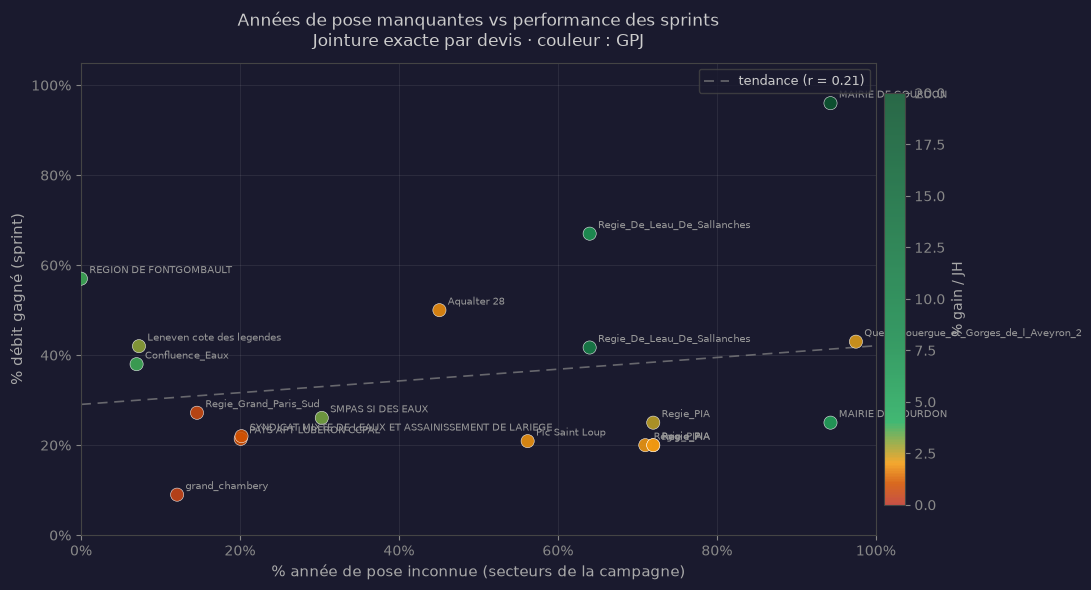

Diamètres manquants vs performance des sprints — 19 points · Pearson -0.24 · Spearman -0.46


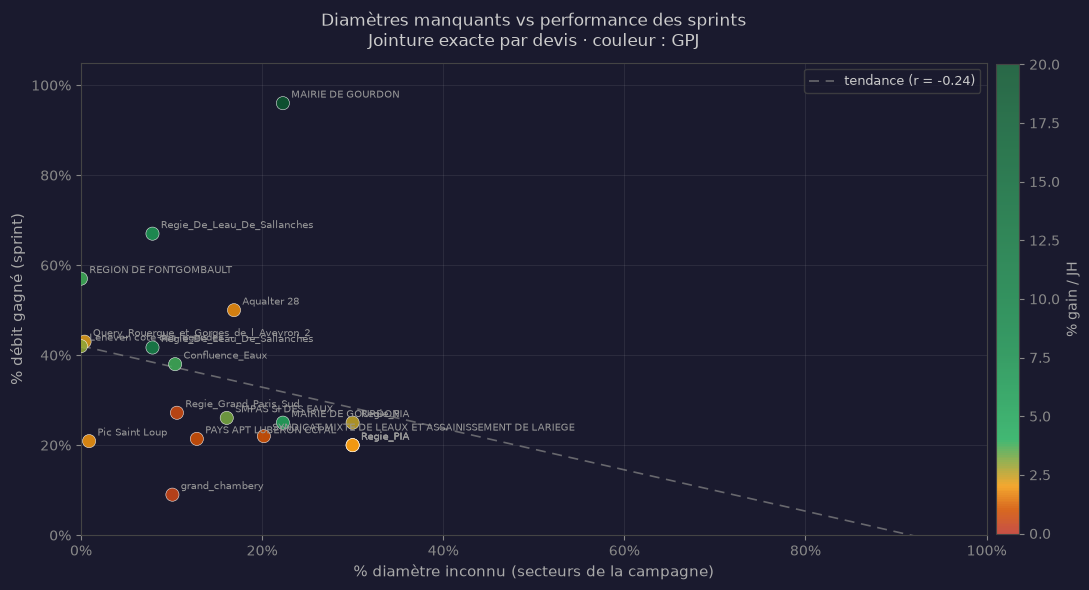

Matériaux manquants vs performance des sprints — 19 points · Pearson 0.25 · Spearman -0.19


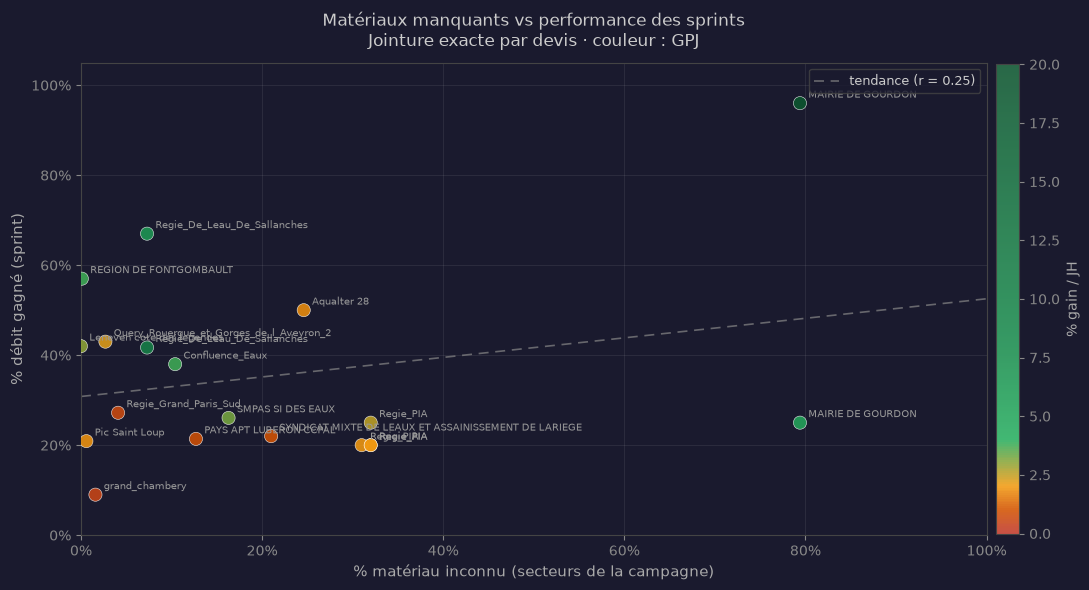

In [ ]:
# ── graphes : donnée manquante (x) vs gain sprint (y), couleur = GPJ ─────────
COLOR_STOPS = [
    (0,  (192,  57, 43)),
    (1,  (211,  84,  0)),
    (2,  (243, 156, 18)),
    (4,  ( 39, 174, 96)),
    (8,  ( 26, 140, 78)),
    (20, ( 11,  83, 46)),
]
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "gpj", [(v / 20, tuple(c / 255 for c in rgb)) for v, rgb in COLOR_STOPS]
)
norm = mcolors.Normalize(vmin=0, vmax=20)

def plot_missing_vs_gain(col, xlabel, title):
    d = df_cmp.dropna(subset=[col])
    if len(d) < 3:
        print(f"{title} — trop peu de points ({len(d)})")
        return
    pearson  = d[col].corr(d["gain_pct"])
    spearman = d[col].corr(d["gain_pct"], method="spearman")
    print(f"{title} — {len(d)} points · Pearson {pearson:.2f} · Spearman {spearman:.2f}")

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("#1a1a2e")
    ax.set_facecolor("#1a1a2e")

    sc = ax.scatter(
        d[col], d["gain_pct"],
        c=d["gpj"], cmap=custom_cmap, norm=norm,
        s=90, edgecolors="white", linewidths=0.4, alpha=0.88, zorder=3,
    )
    for _, r in d.iterrows():
        ax.annotate(r["client"], (r[col], r["gain_pct"]),
                    xytext=(6, 4), textcoords="offset points",
                    fontsize=7, color="#999")

    z = np.polyfit(d[col], d["gain_pct"], 1)
    xs_fit = np.linspace(0, 100, 50)
    ax.plot(xs_fit, np.polyval(z, xs_fit), color="#888",
            linestyle=(0, (6, 4)), linewidth=1.2, alpha=0.7,
            label=f"tendance (r = {pearson:.2f})")
    ax.legend(loc="upper right", facecolor="#1a1a2e", edgecolor="#444",
              labelcolor="#ccc", fontsize=9)

    ax.grid(color="white", alpha=0.08, linewidth=0.7)
    ax.set_axisbelow(True)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 105)
    ax.set_xlabel(xlabel, color="#aaa", fontsize=11)
    ax.set_ylabel("% débit gagné (sprint)", color="#aaa", fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
    ax.tick_params(colors="#888", labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444")
    ax.set_title(f"{title}\nJointure exacte par devis · couleur : GPJ",
                 color="#ccc", fontsize=12, pad=12)

    cbar = fig.colorbar(sc, ax=ax, pad=0.01, fraction=0.025)
    cbar.set_label("% gain / JH", color="#aaa", fontsize=10)
    cbar.ax.yaxis.set_tick_params(color="#888", labelcolor="#888")
    cbar.outline.set_edgecolor("#444")

    plt.tight_layout()
    plt.show()

plot_missing_vs_gain(
    "pct_year_unknown",
    "% année de pose inconnue (secteurs de la campagne)",
    "Années de pose manquantes vs performance des sprints",
)
plot_missing_vs_gain(
    "pct_diameter_unknown",
    "% diamètre inconnu (secteurs de la campagne)",
    "Diamètres manquants vs performance des sprints",
)
plot_missing_vs_gain(
    "pct_material_unknown",
    "% matériau inconnu (secteurs de la campagne)",
    "Matériaux manquants vs performance des sprints",
)